# Predicting TP53 Mutation Status from Gene Expression Profiles

This notebook is the main project report. It is written as a step-by-step analysis, so each section depends on the objects and decisions created in the previous sections.

The biological question is: can RNA-seq expression profiles reveal whether the tumor suppressor gene **TP53** is mutated?

We answer this through two supervised learning tasks:

1. Binary classification: TP53 mutant versus TP53 wild-type.
2. Multi-class classification: broad TP53 mutation type.

The main dataset is CCLE/DepMap because it provides matched cancer cell-line gene expression, mutation calls, and model metadata in a relatively clean format.

## Important Running Note

Run the cells from top to bottom. Later cells reuse variables created earlier, especially the cleaned expression matrix, TP53 labels, train/validation/test split, selected feature sets, and best model.

If the raw DepMap files are already present in `data/raw/`, the notebook will use them. If not, the download cell can fetch them.

## Step 0: Setup

We first import the libraries and local helper functions used throughout the analysis. The helper functions keep repetitive details, such as DepMap gene-name cleaning and TP53 mutation labeling, consistent across the project.

In [22]:
from pathlib import Path
import os
import sys
import warnings

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tp53_ml.config import load_config
from tp53_ml.data import align_metadata, download_depmap_file, make_tp53_labels, read_expression, read_metadata, try_download_candidates
from tp53_ml.evaluation import binary_metrics, multiclass_metrics
from tp53_ml.genes import P53_PATHWAY_GENES, TP53_TARGET_GENES
from tp53_ml.models import binary_model_specs, feature_selectors, make_pipeline, multiclass_model_specs, positive_class_scores, selected_feature_names
from tp53_ml.preprocessing import TopVarianceSelector

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

cfg = load_config("config/project.yaml")
RANDOM_STATE = cfg["project"]["random_state"]

Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/tables").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("models").mkdir(parents=True, exist_ok=True)

ROOT

PosixPath('/Users/markostamenovic/Desktop/MSc CLASSES/ML Lab/TP53-MUTATIONS')

## Step 1: Define the Data Source

The project needs two matched data types for every sample:

- Features: gene expression values across thousands of genes.
- Labels: TP53 mutation status derived from somatic mutation calls.

We use the DepMap public release configured in `config/project.yaml`. Current DepMap releases store protein-coding expression in log-transformed TPM form, which is suitable for machine learning without another log transform.

In [23]:
raw_dir = Path(cfg["data"]["raw_dir"])
raw_dir.mkdir(parents=True, exist_ok=True)

release = cfg["depmap"]["release"]
expression_file = cfg["depmap"]["expression_file"]
mutation_candidates = cfg["depmap"]["mutation_file_candidates"]
metadata_candidates = cfg["depmap"]["metadata_file_candidates"]

expression_path = raw_dir / expression_file
mutation_path = next((raw_dir / name for name in mutation_candidates if (raw_dir / name).exists()), None)
metadata_path = next((raw_dir / name for name in metadata_candidates if (raw_dir / name).exists()), None)

print("DepMap release:", release)
print("Expression file:", expression_path)
print("Mutation file:", mutation_path)
print("Metadata file:", metadata_path)

DepMap release: DepMap Public 26Q1
Expression file: data/raw/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv
Mutation file: data/raw/OmicsSomaticMutations.csv
Metadata file: data/raw/Model.csv


If the files are missing, run the next cell. It is safe to skip it when the paths above already exist and have realistic file sizes.

In [24]:
if not expression_path.exists() or mutation_path is None or metadata_path is None:
    expression_path = download_depmap_file(release, expression_file, raw_dir)
    mutation_path = try_download_candidates(release, mutation_candidates, raw_dir)
    metadata_path = try_download_candidates(release, metadata_candidates, raw_dir)

print("Ready to use:")
print(expression_path)
print(mutation_path)
print(metadata_path)

Ready to use:
data/raw/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv
data/raw/OmicsSomaticMutations.csv
data/raw/Model.csv


## Step 2: Build the Matched Machine-Learning Dataset

The raw expression file contains expression values and a few DepMap metadata columns. The mutation file contains one row per variant. We need one row per sample with a single TP53 label.

For samples with multiple TP53 mutations, we assign the most severe observed consequence. This prevents a sample with both a damaging and a milder TP53 variant from being mislabeled as only the milder type.

In [25]:
X = read_expression(expression_path)
mutations = pd.read_csv(mutation_path, low_memory=False)
metadata_raw = read_metadata(metadata_path)

labels = make_tp53_labels(mutations, X.index)
metadata = align_metadata(metadata_raw, X.index)

assert list(X.index.astype(str)) == labels["sample_id"].astype(str).to_list()
assert list(X.index.astype(str)) == metadata["sample_id"].astype(str).to_list()

X.to_csv(cfg["data"]["expression_processed"], compression="gzip")
labels.to_csv(cfg["data"]["labels_processed"], index=False)
metadata.to_csv(cfg["data"]["metadata_processed"], index=False)

print(f"Matched expression matrix: {X.shape[0]} samples x {X.shape[1]} genes")
print(f"Labels table: {labels.shape}")
print(f"Metadata table: {metadata.shape}")

KeyboardInterrupt: 

## Step 3: Inspect TP53 Label Construction

Before modelling, we check whether the binary classes and mutation-type labels are biologically plausible. TP53 is frequently mutated in cancer, so we expect many mutant samples, but not all samples should be mutant.

In [ ]:
binary_balance = (
    labels["tp53_mutant"]
    .map({0: "WT", 1: "Mutant"})
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)
binary_balance["percentage"] = 100 * binary_balance["count"] / binary_balance["count"].sum()

mutation_balance = labels["mutation_type_collapsed"].value_counts().rename_axis("mutation_type").reset_index(name="count")
mutation_balance["percentage"] = 100 * mutation_balance["count"] / mutation_balance["count"].sum()

display(binary_balance)
display(mutation_balance)

,class,count,percentage
0,Mutant,997,57.998837
1,WT,722,42.001163


,mutation_type,count,percentage
0,WT,722,42.001163
1,Missense,620,36.067481
2,Other,189,10.994764
3,Nonsense,113,6.573589
4,Frameshift,58,3.374055
5,In-frame indel,9,0.523560
6,Synonymous,8,0.465387


The binary task is the core task because it has the cleanest biological definition: a sample either has at least one TP53 mutation call or it does not. The mutation-type task is more difficult because some classes are rare and because mutation type is only an imperfect proxy for functional effect.

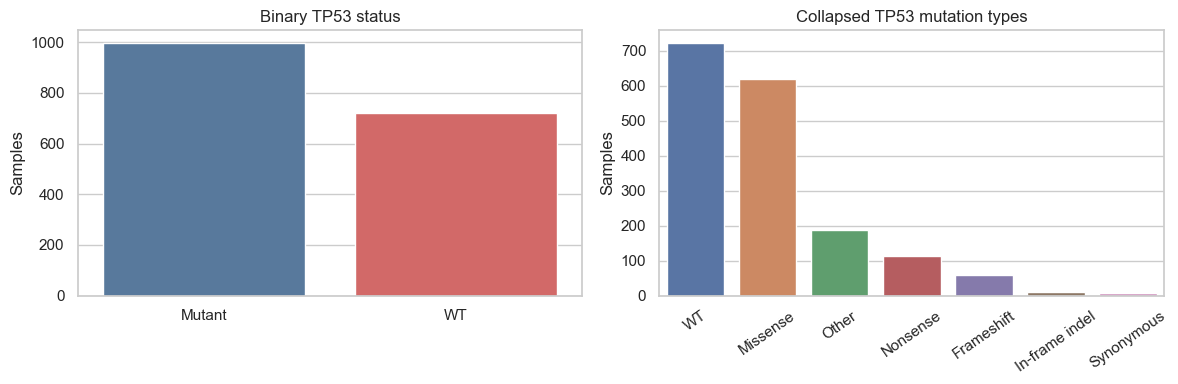

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=binary_balance, x="class", y="count", hue="class", legend=False, ax=axes[0], palette=["#4C78A8", "#E45756"])
axes[0].set_title("Binary TP53 status")
axes[0].set_xlabel("")
axes[0].set_ylabel("Samples")

sns.barplot(data=mutation_balance, x="mutation_type", y="count", hue="mutation_type", legend=False, ax=axes[1])
axes[1].set_title("Collapsed TP53 mutation types")
axes[1].set_xlabel("")
axes[1].set_ylabel("Samples")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## Step 4: Inspect Expression Data

Gene expression data is high dimensional: we have many more genes than samples. This is typical for biomedical machine learning and motivates regularization, feature filtering, and strict leakage prevention.

In [ ]:
expression_summary = pd.DataFrame(
    [
        {"metric": "samples", "value": X.shape[0]},
        {"metric": "genes", "value": X.shape[1]},
        {"metric": "missing_values", "value": int(X.isna().sum().sum())},
        {"metric": "mean_expression", "value": float(X.to_numpy().mean())},
        {"metric": "median_expression", "value": float(pd.Series(X.to_numpy().ravel()).median())},
    ]
)
expression_summary

,metric,value
0,samples,1719.000000
1,genes,19215.000000
2,missing_values,0.000000
3,mean_expression,2.670069
4,median_expression,2.415231


The values are already log-transformed TPM values from DepMap, so we do not apply another log transform. Double-transforming would compress the expression scale unnecessarily.

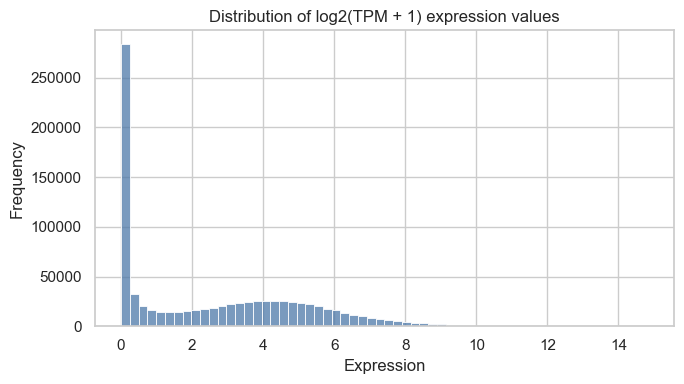

In [ ]:
sampled_genes = X.sample(n=min(500, X.shape[1]), axis=1, random_state=RANDOM_STATE)
plt.figure(figsize=(7, 4))
sns.histplot(sampled_genes.to_numpy().ravel(), bins=60, color="#4C78A8")
plt.title("Distribution of log2(TPM + 1) expression values")
plt.xlabel("Expression")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Step 5: PCA Visualization

PCA is not used to train the final classifiers. It is an exploratory tool to ask whether the dominant expression variation is related to TP53 status or to other biology, such as cancer lineage. Because PCA is fitted here only for visualization, we keep it separate from supervised model training.

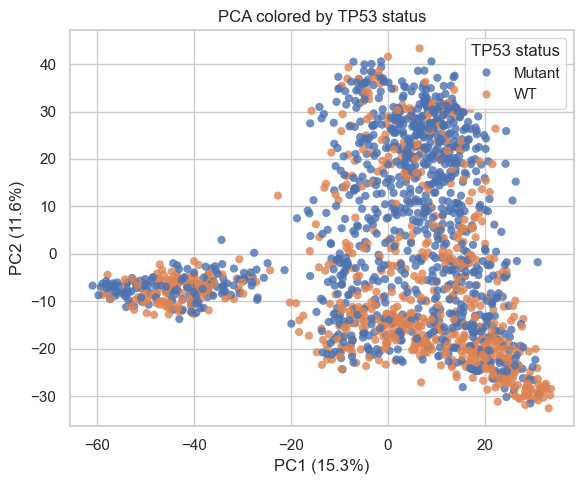

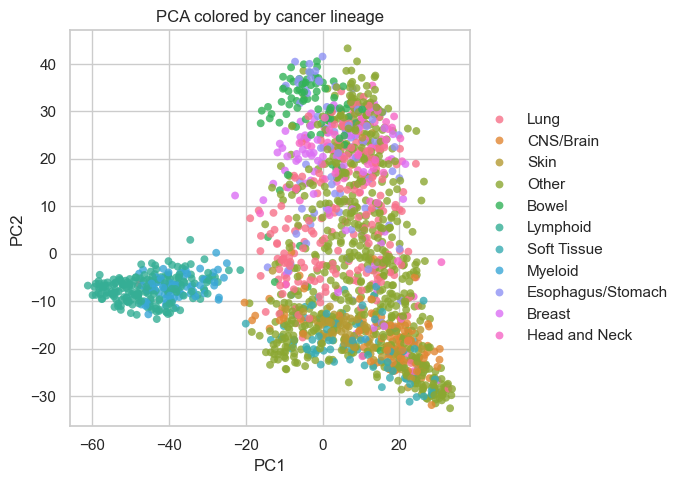

In [ ]:
pca_selector = TopVarianceSelector(k=3000, min_mean_expression=cfg["features"]["min_mean_expression"])
X_pca_features = pca_selector.fit_transform(X)
X_pca_scaled = StandardScaler().fit_transform(X_pca_features)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_pca_scaled)

pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"])
pca_df["sample_id"] = labels["sample_id"].to_numpy()
pca_df["TP53 status"] = labels["tp53_mutant"].map({0: "WT", 1: "Mutant"}).to_numpy()

lineage_col = next((c for c in ["OncotreeLineage", "onCotreeLineage", "lineage", "primary_disease"] if c in metadata.columns), None)
if lineage_col:
    pca_df = pca_df.merge(metadata[["sample_id", lineage_col]], on="sample_id", how="left")
    top_lineages = pca_df[lineage_col].value_counts().head(10).index
    pca_df["lineage_plot"] = pca_df[lineage_col].where(pca_df[lineage_col].isin(top_lineages), "Other")

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="TP53 status", s=35, linewidth=0, alpha=0.8, ax=ax)
ax.set_title("PCA colored by TP53 status")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.tight_layout()
plt.show()

if lineage_col:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="lineage_plot", s=32, linewidth=0, alpha=0.8, ax=ax)
    ax.set_title("PCA colored by cancer lineage")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

## Step 6: Train, Validation, and Test Split

We split after label creation and before supervised preprocessing. This matters because feature selection and scaling must be learned from training data only. If feature filtering used the full dataset before splitting, information from validation or test samples would leak into the model.

In [ ]:
y_binary = labels["tp53_mutant"].astype(int)

X_trainval, X_test, y_trainval, y_test, labels_trainval, labels_test = train_test_split(
    X,
    y_binary,
    labels,
    test_size=cfg["split"]["test_size"],
    stratify=y_binary,
    random_state=RANDOM_STATE,
)

val_fraction = cfg["split"]["validation_size"] / (1 - cfg["split"]["test_size"])
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_fraction,
    stratify=y_trainval,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "samples": [len(y_train), len(y_val), len(y_test)],
        "mutant_fraction": [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)
split_summary

,split,samples,mutant_fraction
0,train,1203,0.579385
1,validation,258,0.581395
2,test,258,0.581395


## Step 7: Define Feature Sets and Binary Models

We compare data-driven and biology-driven feature sets:

- Top variable genes: broad expression signal, less interpretable.
- TP53 target genes: direct biological prior, highly interpretable.
- p53 pathway genes: slightly broader biological prior including DNA damage, apoptosis, and cell-cycle genes.

Each feature selector is placed inside an sklearn pipeline so it is fitted only on the training split.

In [ ]:
selectors = feature_selectors(cfg["features"]["top_variable_genes"], cfg["features"]["min_mean_expression"])
binary_models = binary_model_specs(RANDOM_STATE)

scale_models = {"logistic_l2", "elastic_net_logistic", "linear_svm", "mlp"}

print("Feature sets:", list(selectors))
print("Binary models:", list(binary_models))

Feature sets: ['top_3000_variable', 'tp53_targets', 'p53_pathway']
Binary models: ['majority', 'logistic_l2', 'elastic_net_logistic', 'linear_svm', 'random_forest', 'extra_trees', 'hist_gradient_boosting', 'mlp']


We now train each model on the training split and rank it on the validation split. The test set is untouched until the model choice has been made.

In [ ]:
binary_rows = []
for feature_name, selector in selectors.items():
    for model_name, model in binary_models.items():
        if model_name in {"hist_gradient_boosting", "mlp"} and not feature_name.startswith("top_"):
            continue
        pipe = make_pipeline(selector, model, scale=model_name in scale_models)
        pipe.fit(X_train, y_train)
        y_val_pred = pipe.predict(X_val)
        y_val_score = positive_class_scores(pipe, X_val)
        row = binary_metrics(y_val, y_val_pred, y_val_score)
        row.update({"feature_set": feature_name, "model": model_name})
        binary_rows.append(row)

binary_validation = pd.DataFrame(binary_rows).sort_values(["roc_auc", "balanced_accuracy", "f1"], ascending=False)
binary_validation.to_csv("reports/tables/binary_validation_performance.csv", index=False)
binary_validation.head(12)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,feature_set,model
18,0.899225,0.887407,0.878049,0.960000,0.917197,0.916667,0.890837,p53_pathway,random_forest
16,0.844961,0.842037,0.871622,0.860000,0.865772,0.916296,0.924605,p53_pathway,elastic_net_logistic
19,0.895349,0.882778,0.872727,0.960000,0.914286,0.915432,0.892152,p53_pathway,extra_trees
15,0.856589,0.853333,0.879195,0.873333,0.876254,0.913889,0.918921,p53_pathway,logistic_l2
6,0.852713,0.842222,0.850000,0.906667,0.877419,0.913827,0.918073,top_3000_variable,hist_gradient_boosting
17,0.856589,0.853333,0.879195,0.873333,0.876254,0.912346,0.916205,p53_pathway,linear_svm
10,0.844961,0.836852,0.852564,0.886667,0.869281,0.912037,0.920403,tp53_targets,elastic_net_logistic
9,0.848837,0.841481,0.858065,0.886667,0.872131,0.911235,0.921827,tp53_targets,logistic_l2
13,0.895349,0.882778,0.872727,0.960000,0.914286,0.910802,0.892595,tp53_targets,extra_trees
11,0.852713,0.843519,0.854430,0.900000,0.876623,0.909506,0.918683,tp53_targets,linear_svm


## Step 8: Evaluate the Selected Binary Model on the Test Set

The best model is selected by validation ROC-AUC, with balanced accuracy and F1 as secondary checks. After choosing the model, we retrain it on train + validation data and evaluate once on the held-out test set.

In [ ]:
best_binary_row = binary_validation.iloc[0]
best_feature_set = best_binary_row["feature_set"]
best_model_name = best_binary_row["model"]

best_binary_model = make_pipeline(
    selectors[best_feature_set],
    binary_models[best_model_name],
    scale=best_model_name in scale_models,
)
best_binary_model.fit(X_trainval, y_trainval)

y_test_pred = best_binary_model.predict(X_test)
y_test_score = positive_class_scores(best_binary_model, X_test)
binary_test = pd.DataFrame([
    {
        **binary_metrics(y_test, y_test_pred, y_test_score),
        "feature_set": best_feature_set,
        "model": best_model_name,
    }
])
binary_test.to_csv("reports/tables/binary_test_performance.csv", index=False)
joblib.dump(best_binary_model, "models/best_binary_model.joblib")

display(best_binary_row.to_frame("best_validation_model"))
display(binary_test)

,best_validation_model
accuracy,0.899225
balanced_accuracy,0.887407
precision,0.878049
recall,0.96
f1,0.917197
roc_auc,0.916667
pr_auc,0.890837
feature_set,p53_pathway
model,random_forest


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,feature_set,model
0,0.829457,0.811852,0.811765,0.92,0.8625,0.905617,0.919551,p53_pathway,random_forest


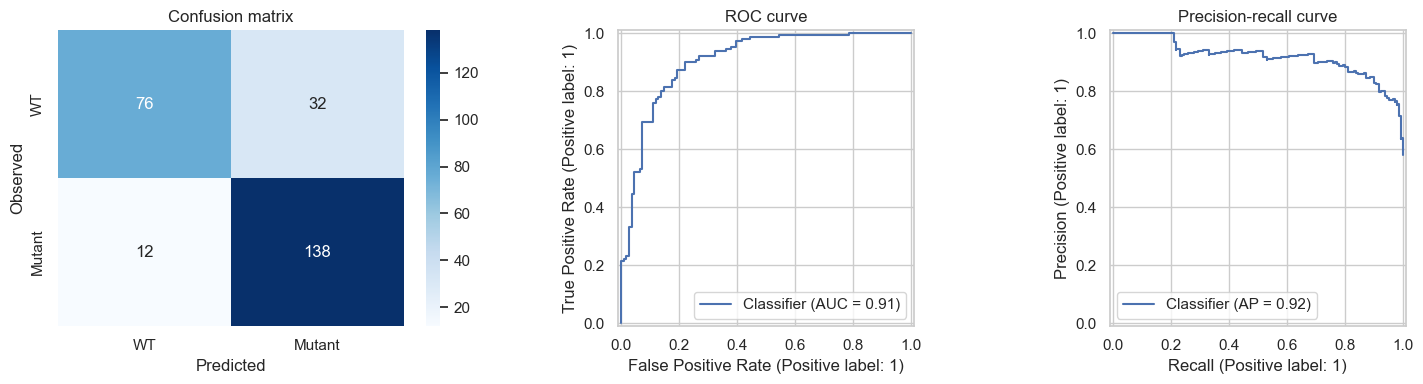

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["WT", "Mutant"], yticklabels=["WT", "Mutant"], ax=axes[0])
axes[0].set_title("Confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Observed")

RocCurveDisplay.from_predictions(y_test, y_test_score, ax=axes[1])
axes[1].set_title("ROC curve")

PrecisionRecallDisplay.from_predictions(y_test, y_test_score, ax=axes[2])
axes[2].set_title("Precision-recall curve")

plt.tight_layout()
plt.show()

## Step 9: Mutation-Type Classification

The second task asks whether expression can distinguish broad TP53 mutation classes. This is biologically harder because mutation class does not always map cleanly onto functional effect, and some classes have very few samples. We therefore remove classes with fewer than 10 samples before training.

In [ ]:
y_type_raw = labels["mutation_type_collapsed"].astype(str)
type_counts = y_type_raw.value_counts()
keep_type = y_type_raw.isin(type_counts[type_counts >= 10].index)

X_type = X.loc[keep_type.to_numpy()]
y_type = y_type_raw.loc[keep_type].reset_index(drop=True)

type_counts_kept = y_type.value_counts().rename_axis("mutation_type").reset_index(name="count")
type_counts_kept

,mutation_type,count
0,WT,722
1,Missense,620
2,Other,189
3,Nonsense,113
4,Frameshift,58


In [ ]:
X_type_trainval, X_type_test, y_type_trainval, y_type_test = train_test_split(
    X_type,
    y_type,
    test_size=cfg["split"]["test_size"],
    stratify=y_type,
    random_state=RANDOM_STATE,
)

X_type_train, X_type_val, y_type_train, y_type_val = train_test_split(
    X_type_trainval,
    y_type_trainval,
    test_size=val_fraction,
    stratify=y_type_trainval,
    random_state=RANDOM_STATE,
)

multiclass_models = multiclass_model_specs(RANDOM_STATE)
multiclass_rows = []
for feature_name, selector in selectors.items():
    for model_name, model in multiclass_models.items():
        pipe = make_pipeline(selector, model, scale=model_name == "logistic_l2")
        pipe.fit(X_type_train, y_type_train)
        pred = pipe.predict(X_type_val)
        row = multiclass_metrics(y_type_val, pred)
        row.update({"feature_set": feature_name, "model": model_name})
        multiclass_rows.append(row)

multiclass_validation = pd.DataFrame(multiclass_rows).sort_values(["macro_f1", "balanced_accuracy", "weighted_f1"], ascending=False)
multiclass_validation.to_csv("reports/tables/multiclass_validation_performance.csv", index=False)
multiclass_validation.head(10)

,accuracy,balanced_accuracy,macro_f1,weighted_f1,feature_set,model
6,0.714844,0.480634,0.480674,0.698071,tp53_targets,random_forest
7,0.703125,0.449276,0.455723,0.680030,tp53_targets,extra_trees
10,0.726562,0.450986,0.451582,0.699825,p53_pathway,random_forest
9,0.609375,0.447681,0.429592,0.634450,p53_pathway,logistic_l2
11,0.683594,0.383772,0.378107,0.644039,p53_pathway,extra_trees
5,0.562500,0.360564,0.365997,0.596566,tp53_targets,logistic_l2
1,0.574219,0.332800,0.331396,0.561768,top_3000_variable,logistic_l2
2,0.597656,0.302516,0.267498,0.532141,top_3000_variable,random_forest
3,0.582031,0.293913,0.260277,0.517834,top_3000_variable,extra_trees
0,0.425781,0.200000,0.119452,0.254302,top_3000_variable,majority


,best_validation_model
accuracy,0.714844
balanced_accuracy,0.480634
macro_f1,0.480674
weighted_f1,0.698071
feature_set,tp53_targets
model,random_forest


,accuracy,balanced_accuracy,macro_f1,weighted_f1,feature_set,model
0,0.714844,0.449211,0.447827,0.690331,tp53_targets,random_forest


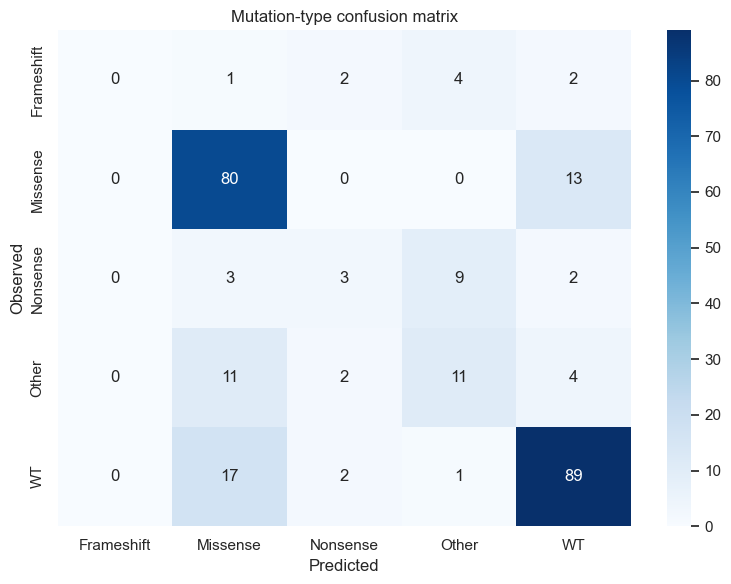

In [ ]:
best_type_row = multiclass_validation.iloc[0]
best_type_model = make_pipeline(
    selectors[best_type_row["feature_set"]],
    multiclass_models[best_type_row["model"]],
    scale=best_type_row["model"] == "logistic_l2",
)
best_type_model.fit(X_type_trainval, y_type_trainval)
y_type_pred = best_type_model.predict(X_type_test)

multiclass_test = pd.DataFrame([
    {**multiclass_metrics(y_type_test, y_type_pred), "feature_set": best_type_row["feature_set"], "model": best_type_row["model"]}
])
multiclass_test.to_csv("reports/tables/multiclass_test_performance.csv", index=False)
joblib.dump(best_type_model, "models/best_multiclass_model.joblib")

display(best_type_row.to_frame("best_validation_model"))
display(multiclass_test)

ordered_type_labels = sorted(y_type.unique())
cm_type = confusion_matrix(y_type_test, y_type_pred, labels=ordered_type_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_type, annot=True, fmt="d", cmap="Blues", xticklabels=ordered_type_labels, yticklabels=ordered_type_labels)
plt.title("Mutation-type confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.tight_layout()
plt.show()

## Step 10: Interpret the Best Binary Model

Interpretation is essential here because the goal is not only prediction. We want to know whether the expression features selected by the model make sense in relation to TP53 biology.

For coefficient-based models we inspect absolute coefficients. For tree-based models we inspect feature importance. We then compare important genes with curated TP53 target and p53 pathway genes.

,gene,importance,abs_importance
34,MDM2,0.090885,0.090885
61,ZMAT3,0.073021,0.073021
23,CDKN1A,0.071180,0.071180
5,BAX,0.040709,0.040709
50,SESN1,0.038744,0.038744
49,RRM2B,0.034256,0.034256
52,SFN,0.030193,0.030193
55,TNFRSF10B,0.026597,0.026597
42,PHLDA3,0.025578,0.025578
27,DRAM1,0.023507,0.023507


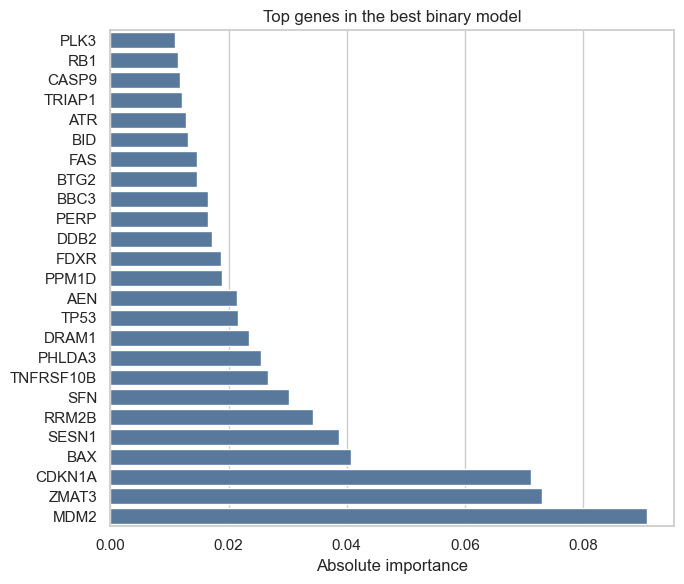

In [ ]:
feature_names = selected_feature_names(best_binary_model)
model = best_binary_model.named_steps["model"]

if hasattr(model, "coef_"):
    importance_values = np.ravel(model.coef_)
elif hasattr(model, "feature_importances_"):
    importance_values = model.feature_importances_
else:
    importance_values = None

if importance_values is not None:
    top_model_genes = (
        pd.DataFrame({"gene": feature_names, "importance": importance_values, "abs_importance": np.abs(importance_values)})
        .sort_values("abs_importance", ascending=False)
        .head(100)
    )
    top_model_genes.to_csv("reports/tables/binary_best_model_top_genes.csv", index=False)
    display(top_model_genes.head(20))

    plt.figure(figsize=(7, 6))
    sns.barplot(data=top_model_genes.head(25).iloc[::-1], x="abs_importance", y="gene", color="#4C78A8")
    plt.title("Top genes in the best binary model")
    plt.xlabel("Absolute importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    top_model_genes = pd.DataFrame(columns=["gene", "importance", "abs_importance"])
    print("The selected model does not expose direct feature importance.")

## Step 11: Differential Expression Between TP53 Mutant and WT Samples

Differential expression is not used to train the models. It is used after modelling as a biological interpretation check: do genes that differ between mutant and wild-type samples overlap with p53 targets or the model's important genes?

In [ ]:
labels_indexed = labels.set_index("sample_id")
y_for_de = labels_indexed.loc[X.index, "tp53_mutant"]
mutant_expression = X.loc[y_for_de == 1]
wt_expression = X.loc[y_for_de == 0]

de_rows = []
for gene in X.columns:
    mut_values = mutant_expression[gene]
    wt_values = wt_expression[gene]
    stat = ttest_ind(mut_values, wt_values, equal_var=False, nan_policy="omit")
    de_rows.append(
        {
            "gene": gene,
            "mean_mutant": mut_values.mean(),
            "mean_wt": wt_values.mean(),
            "difference_mutant_minus_wt": mut_values.mean() - wt_values.mean(),
            "p_value": stat.pvalue,
        }
    )

de_table = pd.DataFrame(de_rows)
de_table["rank_p"] = de_table["p_value"].rank(method="first")
de_table["fdr_bh"] = (de_table["p_value"] * len(de_table) / de_table["rank_p"]).clip(upper=1.0)
de_table = de_table.sort_values(["fdr_bh", "p_value"])
de_table.to_csv("reports/tables/differential_expression_tp53_mutant_vs_wt.csv", index=False)
de_table.head(20)

,gene,mean_mutant,mean_wt,difference_mutant_minus_wt,p_value,rank_p,fdr_bh
6281,EDA2R,0.369827,2.163987,-1.794160,3.925008e-131,1.0,7.541902e-127
15158,RPS27L,6.404370,7.578244,-1.173874,1.666730e-113,2.0,1.601310e-109
5487,CDKN1A,4.700432,6.641905,-1.941473,3.580774e-107,3.0,2.293486e-103
6996,MDM2,4.711485,6.031187,-1.319702,9.551311e-98,4.0,4.588211e-94
13044,ZMAT3,2.701493,3.906226,-1.204732,8.649890e-97,5.0,3.324153e-93
1703,BAX,6.600468,7.253759,-0.653291,5.261418e-67,6.0,1.684969e-63
634,RRM2B,3.959146,4.790120,-0.830974,5.681072e-65,7.0,1.559454e-61
1484,SESN1,2.827146,3.695974,-0.868828,1.653752e-63,8.0,3.972107e-60
6796,DDB2,4.472230,5.182435,-0.710205,2.359904e-52,9.0,5.038396e-49
10695,SPATA18,0.354450,1.204454,-0.850004,2.699473e-52,10.0,5.187037e-49


## Step 12: Biological Overlap Summary

Now we connect the statistical results back to biology. A strong project result is not only high AUC; it is high AUC supported by genes that make sense for TP53 transcriptional activity.

In [ ]:
top_n = 100
top_de_genes = set(de_table.head(top_n)["gene"])
top_model_gene_set = set(top_model_genes.head(top_n)["gene"])

overlap_summary = pd.DataFrame(
    [
        {
            "comparison": "Top DE genes vs TP53 targets",
            "overlap_count": len(top_de_genes & set(TP53_TARGET_GENES)),
            "genes": ";".join(sorted(top_de_genes & set(TP53_TARGET_GENES))),
        },
        {
            "comparison": "Top DE genes vs p53 pathway",
            "overlap_count": len(top_de_genes & set(P53_PATHWAY_GENES)),
            "genes": ";".join(sorted(top_de_genes & set(P53_PATHWAY_GENES))),
        },
        {
            "comparison": "Top model genes vs TP53 targets",
            "overlap_count": len(top_model_gene_set & set(TP53_TARGET_GENES)),
            "genes": ";".join(sorted(top_model_gene_set & set(TP53_TARGET_GENES))),
        },
        {
            "comparison": "Top model genes vs p53 pathway",
            "overlap_count": len(top_model_gene_set & set(P53_PATHWAY_GENES)),
            "genes": ";".join(sorted(top_model_gene_set & set(P53_PATHWAY_GENES))),
        },
    ]
)
overlap_summary.to_csv("reports/tables/biological_overlap_summary.csv", index=False)
overlap_summary

,comparison,overlap_count,genes
0,Top DE genes vs TP53 targets,16,AEN;BAX;BBC3;CDKN1A;DDB2;DRAM1;FAS;FDXR;MDM2;PHLDA3;RRM2B;SESN1;SFN;TNFRSF10B;TRIAP1;ZMAT3
1,Top DE genes vs p53 pathway,16,AEN;BAX;BBC3;CDKN1A;DDB2;DRAM1;FAS;FDXR;MDM2;PHLDA3;RRM2B;SESN1;SFN;TNFRSF10B;TRIAP1;ZMAT3
2,Top model genes vs TP53 targets,33,AEN;APAF1;BAX;BBC3;BTG2;CASP1;CD82;CDKN1A;DDB2;DRAM1;EI24;FAS;FDXR;GADD45A;MDM2;PANK1;PERP;PHLDA3;PLK3;PMAIP1;PPM1D;...
3,Top model genes vs p53 pathway,62,AEN;APAF1;ATM;ATR;BAK1;BAX;BBC3;BCL2;BCL2L1;BID;BRCA1;BRCA2;BTG2;CASP1;CASP3;CASP8;CASP9;CCND1;CCNE1;CD82;CDK2;CDK4;...


## Step 13: Final Interpretation

The binary TP53 mutation task is the strongest result. A model trained on p53 pathway genes can predict TP53 mutant versus wild-type samples with high ROC-AUC and PR-AUC. This supports the idea that TP53 mutation status is reflected in downstream transcriptional patterns.

The mutation-type task is weaker. This is expected because mutation type is more granular, class imbalance is stronger, and expression may reflect functional TP53 activity more than the exact DNA-level variant category.

The most important binary-model genes and top differential-expression genes include canonical p53-related genes such as `MDM2`, `CDKN1A`, `BAX`, `BBC3`, `RRM2B`, `ZMAT3`, `SFN`, and `TNFRSF10B`. This makes the prediction result biologically credible rather than purely statistical.

In [ ]:
summary = {
    "samples": X.shape[0],
    "genes": X.shape[1],
    "binary_best_feature_set": best_feature_set,
    "binary_best_model": best_model_name,
    "binary_test_roc_auc": float(binary_test.loc[0, "roc_auc"]),
    "binary_test_pr_auc": float(binary_test.loc[0, "pr_auc"]),
    "binary_test_f1": float(binary_test.loc[0, "f1"]),
    "multiclass_best_feature_set": best_type_row["feature_set"],
    "multiclass_best_model": best_type_row["model"],
    "multiclass_test_macro_f1": float(multiclass_test.loc[0, "macro_f1"]),
}
pd.Series(summary).to_frame("project_summary")

,project_summary
samples,1719
genes,19215
binary_best_feature_set,p53_pathway
binary_best_model,random_forest
binary_test_roc_auc,0.905617
binary_test_pr_auc,0.919551
binary_test_f1,0.8625
multiclass_best_feature_set,tp53_targets
multiclass_best_model,random_forest
multiclass_test_macro_f1,0.447827
